In [25]:
from pathlib import Path
import pandas as pd
import numpy as np

from scipy.stats import linregress

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

DATA_PATH = Path("../data/processed")

In [2]:
nav_history = pd.read_csv(
    DATA_PATH / "02_nav_history_clean.csv"
)

performance = pd.read_csv(
    DATA_PATH / "07_scheme_performance_clean.csv"
)

fund_master = pd.read_csv(
    DATA_PATH / "01_fund_master_clean.csv"
)

benchmark_indices = pd.read_csv(
    DATA_PATH / "10_benchmark_indices_clean.csv"
)

In [3]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)
nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [4]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

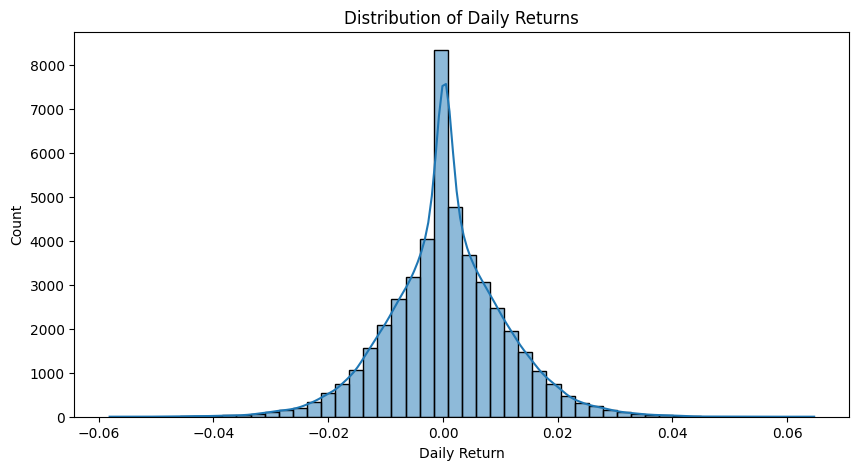

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")

plt.show()

### Daily Return Validation

Daily returns were calculated for all 40 mutual fund schemes using percentage change in NAV. The distribution is centered close to zero and exhibits a reasonable spread without extreme outliers, indicating that the return calculations are valid and suitable for further performance analysis.

In [12]:
nav_history = nav_history.sort_values(["amfi_code", "date"])

def calculate_cagr(start_nav, end_nav, years):

    return (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    )
cagr_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ].sort_values("date")

    try:

        nav_start = fund_data.iloc[0]["nav"]
        nav_end = fund_data.iloc[-1]["nav"]

        cagr_5yr = calculate_cagr(
            nav_start,
            nav_end,
            5
        )

        cagr_3yr = calculate_cagr(
            nav_start,
            nav_end,
            3
        )

        cagr_1yr = calculate_cagr(
            nav_start,
            nav_end,
            1
        )

        cagr_results.append(
            [
                fund,
                cagr_1yr,
                cagr_3yr,
                cagr_5yr
            ]
        )

    except:
        pass


In [13]:
cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
)
cagr_df[
    ["cagr_1yr",
     "cagr_3yr",
     "cagr_5yr"]
] *= 100



In [14]:
cagr_df.head()
cagr_df.sort_values(
    "cagr_5yr",
    ascending=False
).head(10)


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
25,120505,248.684056,51.638925,28.376762
21,119598,244.043537,50.963214,28.033224
39,149324,242.490579,50.735731,27.917430
36,148569,238.658097,50.171374,27.629860
34,148567,227.781083,48.546114,26.799277
30,120843,227.047809,48.435261,26.742494
2,100033,218.514228,47.132838,26.074068
38,149323,212.717589,46.234812,25.611807
16,119094,198.464473,43.978468,24.445309
19,119551,174.560913,40.027361,22.384873


In [15]:

cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

### CAGR Analysis

The CAGR comparison highlights the long-term growth performance of mutual fund schemes. Several funds delivered strong annualized returns over the analysis period, demonstrating consistent wealth creation potential for long-term investors.

In [16]:
RF_ANNUAL = 0.065

RF_DAILY = RF_ANNUAL / 252

sharpe_results = []

for fund in nav_history["amfi_code"].unique():

    returns = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]["daily_return"]
        .dropna()
    )

    avg_return = returns.mean()

    std_return = returns.std()

    sharpe_ratio = (
        (avg_return - RF_DAILY)
        /
        std_return
    ) * np.sqrt(252)

    sharpe_results.append(
        [fund, sharpe_ratio]
    )
sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)


In [17]:
sharpe_df["sharpe_rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [18]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio,sharpe_rank
34,148567,1.448291,1.0
30,120843,1.306744,2.0
36,148569,1.234930,3.0
19,119551,1.208267,4.0
25,120505,1.180101,5.0
38,149323,1.132122,6.0
2,100033,1.093699,7.0
9,118632,1.081659,8.0
3,101206,1.027213,9.0
24,120504,1.026524,10.0


In [19]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio_rankings.csv",
    index=False
)

### Sharpe Ratio Analysis

The Sharpe Ratio evaluates risk-adjusted performance by comparing excess returns to overall volatility. Funds with higher Sharpe Ratios delivered superior returns for each unit of risk taken, making them attractive from a risk-return perspective.

In [20]:
sortino_results = []
for fund in nav_history["amfi_code"].unique():

    returns = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]["daily_return"]
        .dropna()
    )

    avg_return = returns.mean()

    downside_returns = returns[
        returns < 0
    ]

    downside_std = downside_returns.std()

    sortino_ratio = (
        (avg_return - RF_DAILY)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [fund, sortino_ratio]
    )

In [21]:
sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)
sortino_df["sortino_rank"] = (
    sortino_df["sortino_ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [22]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio,sortino_rank
34,148567,2.385644,1.0
30,120843,2.364320,2.0
36,148569,2.146914,3.0
19,119551,2.140267,4.0
25,120505,2.029353,5.0
38,149323,1.875101,6.0
9,118632,1.850133,7.0
2,100033,1.829134,8.0
24,120504,1.805294,9.0
3,101206,1.799563,10.0


In [23]:
sortino_df.to_csv(
    "../reports/sortino_ratio_rankings.csv",
    index=False
)

### Sortino Ratio Analysis

Unlike the Sharpe Ratio, the Sortino Ratio considers only downside volatility. Funds with higher Sortino Ratios generated stronger returns while minimizing harmful downside risk, making them attractive for risk-conscious investors.

In [49]:
nifty100 = benchmark_indices[
    benchmark_indices["index_name"] == "NIFTY100"
].copy()
nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values(
    "date"
)
nifty100["market_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [50]:
alpha_beta_results = []

for fund in nav_history["amfi_code"].unique():

    fund_returns = (
        nav_history[
            nav_history["amfi_code"] == fund
        ][["date", "daily_return"]]
        .copy()
    )

    merged = pd.merge(
        fund_returns,
        nifty100[["date", "market_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["market_return"],
            merged["daily_return"]
        )

        beta = slope

        alpha = intercept * 252

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

In [47]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [57]:
drawdown_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]
        .sort_values("date")
        .copy()
    )

    fund_data["running_max"] = (
        fund_data["nav"]
        .cummax()
    )

    fund_data["drawdown"] = (
        fund_data["nav"]
        /
        fund_data["running_max"]
        - 1
    )

    max_dd = fund_data["drawdown"].min()

    worst_row = fund_data.loc[
        fund_data["drawdown"].idxmin()
    ]

    drawdown_results.append(
        [
            fund,
            max_dd,
            worst_row["date"]
        ]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown",
        "worst_drawdown_date"
    ]
)

In [58]:
drawdown_df["drawdown_rank"] = (
    drawdown_df["max_drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [61]:
return_rank_df = performance[
    ["amfi_code", "return_3yr_pct", "expense_ratio_pct"]
].copy()

return_rank_df["return_rank"] = (
    return_rank_df["return_3yr_pct"]
    .rank(
        ascending=False,
        method="dense"
    )
)

return_rank_df["expense_rank"] = (
    return_rank_df["expense_ratio_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [63]:
scorecard = (
    return_rank_df
    .merge(
        sharpe_df[
            ["amfi_code", "sharpe_rank"]
        ],
        on="amfi_code"
    )
    .merge(
        alpha_beta_df[
            ["amfi_code", "alpha"]
        ],
        on="amfi_code"
    )
    .merge(
        drawdown_df[
            ["amfi_code", "drawdown_rank"]
        ],
        on="amfi_code"
    )
)

In [64]:
scorecard.head()

,amfi_code,return_3yr_pct,expense_ratio_pct,return_rank,expense_rank,sharpe_rank,alpha,drawdown_rank
0,119551,12.36,1.54,26.0,24.0,4.0,0.232010,17.0
1,119552,11.30,0.66,34.0,4.0,12.0,0.198686,11.0
2,119598,23.39,1.43,1.0,18.0,14.0,0.303370,36.0
3,119599,23.14,0.72,2.0,5.0,32.0,0.048824,40.0
4,119120,6.07,0.77,38.0,8.0,37.0,0.056209,5.0


In [67]:
max_rank = scorecard[
    [
        "return_rank",
        "sharpe_rank",
        "alpha",
        "expense_rank",
        "drawdown_rank"
    ]
].max().max()

scorecard["return_score"] = (
    max_rank - scorecard["return_rank"] + 1
)

scorecard["sharpe_score"] = (
    max_rank - scorecard["sharpe_rank"] + 1
)

scorecard["alpha_score"] = (
    max_rank - scorecard["alpha"] + 1
)

scorecard["expense_score"] = (
    max_rank - scorecard["expense_rank"] + 1
)

scorecard["drawdown_score"] = (
    max_rank - scorecard["drawdown_rank"] + 1
)

scorecard["fund_score"] = (

    0.30 * scorecard["return_score"]

    + 0.25 * scorecard["sharpe_score"]

    + 0.20 * scorecard["alpha_score"]

    + 0.15 * scorecard["expense_score"]

    + 0.10 * scorecard["drawdown_score"]

)

In [69]:
scorecard["fund_score"] = (
    scorecard["fund_score"]
    /
    scorecard["fund_score"].max()
    * 100
)

scorecard["fund_score"] = (
    scorecard["fund_score"]
    .round(2)
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard["overall_rank"] = range(
    1,
    len(scorecard) + 1
)

In [70]:
scorecard[
    [
        "overall_rank",
        "amfi_code",
        "fund_score"
    ]
].head(10)

,overall_rank,amfi_code,fund_score
22,1,120843,100.00
12,2,120505,99.08
7,3,100033,96.82
34,4,148567,96.37
2,5,119598,93.47
38,6,149323,91.06
11,7,120504,89.73
39,8,149324,87.56
26,9,119094,86.82
3,10,119599,83.77


In [71]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

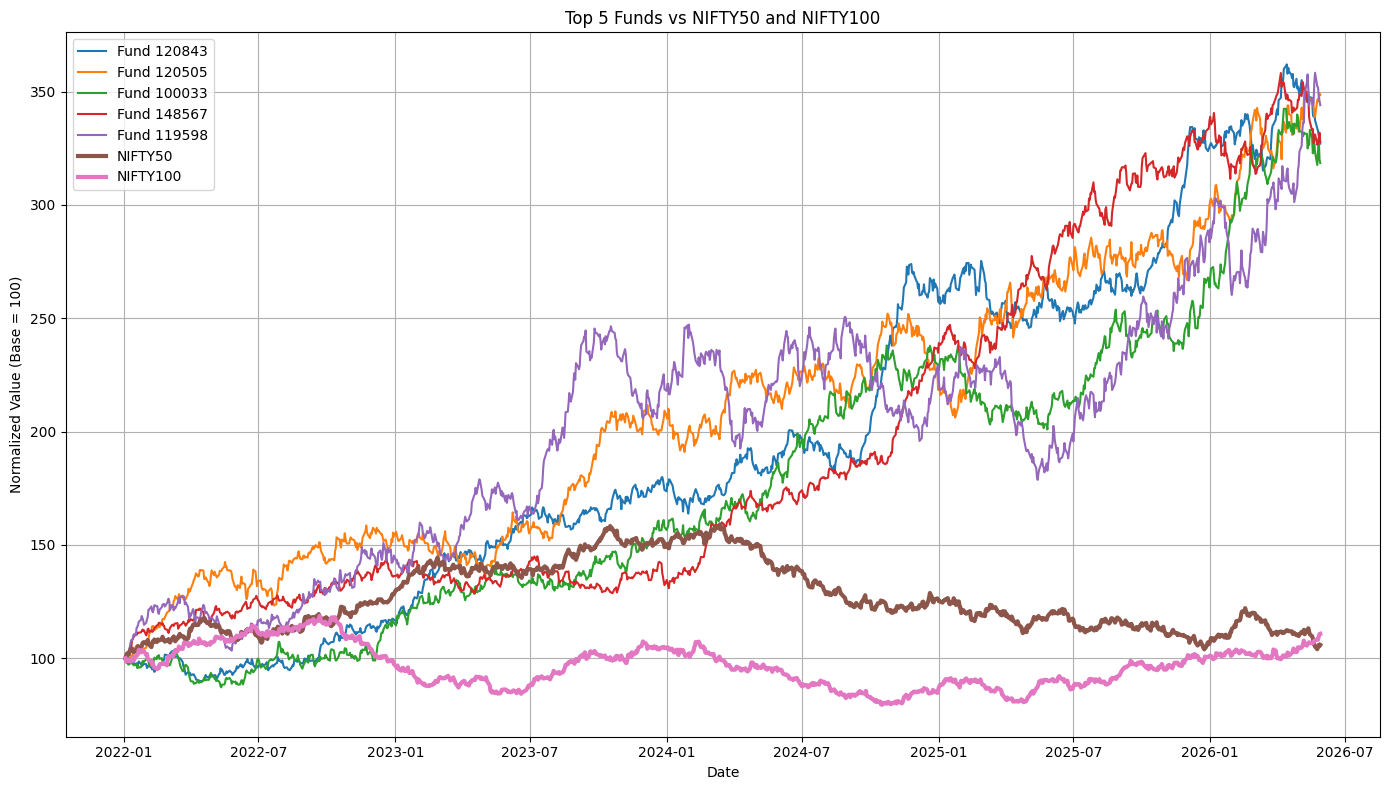

<Figure size 640x480 with 0 Axes>

In [88]:
top5_funds = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)



nifty50 = benchmark_indices[
    benchmark_indices["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark_indices[
    benchmark_indices["index_name"] == "NIFTY100"
].copy()



nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)



nifty50 = nifty50.sort_values("date")

nifty100 = nifty100.sort_values("date")

nifty50["normalized"] = (
    nifty50["close_value"]
    /
    nifty50["close_value"].iloc[0]
) * 100

nifty100["normalized"] = (
    nifty100["close_value"]
    /
    nifty100["close_value"].iloc[0]
) * 100



plt.figure(figsize=(14,8))



for fund in top5_funds:

    fund_data = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]
        .sort_values("date")
        .copy()
    )

    fund_data["normalized"] = (
        fund_data["nav"]
        /
        fund_data["nav"].iloc[0]
    ) * 100

    plt.plot(
        fund_data["date"],
        fund_data["normalized"],
        label=f"Fund {fund}"
    )



plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    label="NIFTY50",
    linewidth=3
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    label="NIFTY100",
    linewidth=3
)

plt.title(
    "Top 5 Funds vs NIFTY50 and NIFTY100"
)

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

In [91]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)
tracking_error_results = []

for fund in top5_funds:

    fund_data = (
        nav_history[
            nav_history["amfi_code"] == fund
        ][["date", "daily_return"]]
        .copy()
    )

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        )
        .std()
        *
        np.sqrt(252)
    )

    tracking_error_results.append(
        [
            fund,
            tracking_error
        ]
    )

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)